In [16]:
# 爬取50条数据


# 1.导入相关库
import requests
import pandas as pd

# 2.使用新浪新闻api
api_url ='https://feed.mix.sina.com.cn/api/roll/get?pageid=153&lid=2516&k=&num=50&page=1'
headers = { 'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Referer': 'https://news.sina.com.cn/'}
# 3.发送请求
response = requests.get(api_url, headers=headers)
response.encoding = 'utf-8'
data = response.json()

# 4.提取新闻数据
news_list = []
for item in data['result']['data']:
    news_list.append({
        'title': item['title'],
        'link': item['url'],
        'time': item['ctime']
    })

# 5.保存数据
df = pd.DataFrame(news_list)
df.to_csv('./data/news_data.csv', index=False, encoding='utf-8')
print(f"找到 {len(data['result']['data'])} 个新闻项")

找到 50 个新闻项


In [21]:
# 一 爬取数据(爬取200条数据)


# 1.导入相关库
import requests
import pandas as pd
import time

# 2.使用新浪新闻api
api_url = 'https://feed.mix.sina.com.cn/api/roll/get?pageid=153&lid=2516&k=&num=50&page={}'
headers = { 'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Referer': 'https://news.sina.com.cn/'}

# 3.分页获取多页数据
news_list = []
for page in range(1,5):
    try:
        response = requests.get(api_url.format(page), headers=headers)
        response.encoding = 'utf-8'
        data = response.json()
        
        if data['result']['status']['code'] == 0:
            for item in data['result']['data']:
                news_list.append({
                    'title': item['title'],
                    'link': item['url'],
                    'time': item['ctime']
                })
            print(f"第 {page} 页数据获取成功")
        else:
            print(f"第 {page} 页数据获取失败")
    except Exception as e:
        print(f"第 {page} 页数据获取异常: {e}")
    time.sleep(1)

# 4.保存数据
df = pd.DataFrame(news_list)
df.to_csv('./data/news_data200.csv', index=False, encoding='utf-8')
print(f"找到 {len(news_list)} 个新闻项")

第 1 页数据获取成功
第 2 页数据获取成功
第 3 页数据获取成功
第 4 页数据获取成功
找到 200 个新闻项


In [46]:
# 二 pandas清洗数据

# 1.导入相关库
import pandas as pd
import re  # 文本清洗

# 2.读取数据
df = pd.read_csv('./data/news_data200.csv', encoding='utf-8')

# 3.查看数据基本信息

# 4.处理缺失值

# 5.去重
df.drop_duplicates(subset=['title'], keep = 'first')

# 6.时间格式统一
df['time'] = pd.to_datetime(df['time'],errors = 'coerce',unit='s') # 统一时间
df = df.dropna(subset = ['time'])
df.head(20)

# 7.文本清洗
def clean_text(text):
    # 去除HTML标签
    text = re.sub(r"<.*?>","" ,text)
    # 去除特殊字符
    text = re.sub(r"[^\u4e00-\u9fa5a-zA-Z0-9]", " ", text)
    # 去除多余的空格
    text = re.sub(r"\s+", " ", text).strip()
    return text
df['title'] = df['title'].apply(clean_text)

# 8.保存清洗后的数据
df.to_csv('./data/news_data200_clean.csv', index=False, encoding='utf-8')
print(f'清洗完成,最终数据量: {len(df)}')

清洗完成,最终数据量: 200


In [49]:
# 三 文本预处理

# 1.导入相关库
import jieba

# 2.加载停用词表
stopwords = set(["的","了", "是", "在", "和", "也", "都", "就", "而", "及", "与", "等", "中", "有", "不", "为", "以", "对", "被", "所", "从", "向", "到", "又", "或", "但", "且", "这", "那", "个", "一", "二", "三", "四", "五", "六", "七", "八", "九", "十"])

# 3.分词函数
def cut_text(text):
    words = jieba.lcut(text)
    words = [word for word in words if word not in stopwords and len(word) > 1]
    return ' '.join(words)

# 4.对清洗后的文本分词
df['cut_title'] = df['title'].apply(cut_text)

# 5.查看分词结果
print(df['cut_title'].head())


0           日本公司 Terra Drone 扩大 乌克兰 无人机 行业 投资
1                 中方 禁止 外资 收购 Manus 项目 外交部 回应
2       高市 称为 长期 战争 做好 准备 外交部 日本 是不是 重蹈 历史 覆辙
3    投资者 SpaceX 人工智能 企业 上市 浪潮 人工智能 产业布局 下潜 风险
4           日本自民党 保守派 参拜 靖国神社 外交部 强烈 愤慨 严厉 谴责
Name: cut_title, dtype: str


In [51]:
# 四 数据分析(词频统计)

# 1.导入相关库
from collections import Counter
import itertools

# 2.合并所有分词结果
all_words = list(itertools.chain(*df['cut_title'].str.split()))

# 3.统计词频
word_counts = Counter(all_words)

# 4.取TOP20高频词
top20_words = word_counts.most_common(20)
print(top20_words)
for word,count in top20_words:
    print(f"{word}: {count}次")

[('港元', 26), ('期货', 19), ('28', 19), ('维持', 17), ('目标价', 16), ('涨超', 16), ('评级', 14), ('第一季度', 13), ('每股', 13), ('净利润', 12), ('归母', 12), ('万股', 12), ('美国', 11), ('伊朗', 10), ('买入', 10), ('黄金', 10), ('合作', 9), ('增持', 9), ('市场', 9), ('科技', 9)]
港元: 26次
期货: 19次
28: 19次
维持: 17次
目标价: 16次
涨超: 16次
评级: 14次
第一季度: 13次
每股: 13次
净利润: 12次
归母: 12次
万股: 12次
美国: 11次
伊朗: 10次
买入: 10次
黄金: 10次
合作: 9次
增持: 9次
市场: 9次
科技: 9次


In [57]:
# 五 数据分析(不同类别新闻占比)

# 1.定义函数,从url中提取新闻类别
def extract_category(url):
    parts = url.split('/')  # 提取url路径部分
    for part in parts:
        if part in ['stock', 'jjxw', 'money', 'tech', 'roll', 'china', 'wm', 'tob', 'fund']:
            return part
    return '其他'

# 2.创建新闻类别列
df['category'] = df['link'].apply(extract_category)

# 3.统计各类别数量
category_counts = df['category'].value_counts()

# 4.计算占比
category_percentage = category_counts / len(df) * 100

# 5.显示结果
print(f'新闻类别统计:{category_counts}')
print(f'新闻类别占比:{category_percentage}')

新闻类别统计:category
stock    139
money     31
jjxw      11
roll       8
wm         7
tech       2
china      1
tob        1
Name: count, dtype: int64
新闻类别占比:category
stock    69.5
money    15.5
jjxw      5.5
roll      4.0
wm        3.5
tech      1.0
china     0.5
tob       0.5
Name: count, dtype: float64


In [58]:
# 六 数据分析(时间趋势分析)

# 所爬取数据集只有200条,发布时间均为4.27/4.28,无法进行时间趋势分析,直接跳过

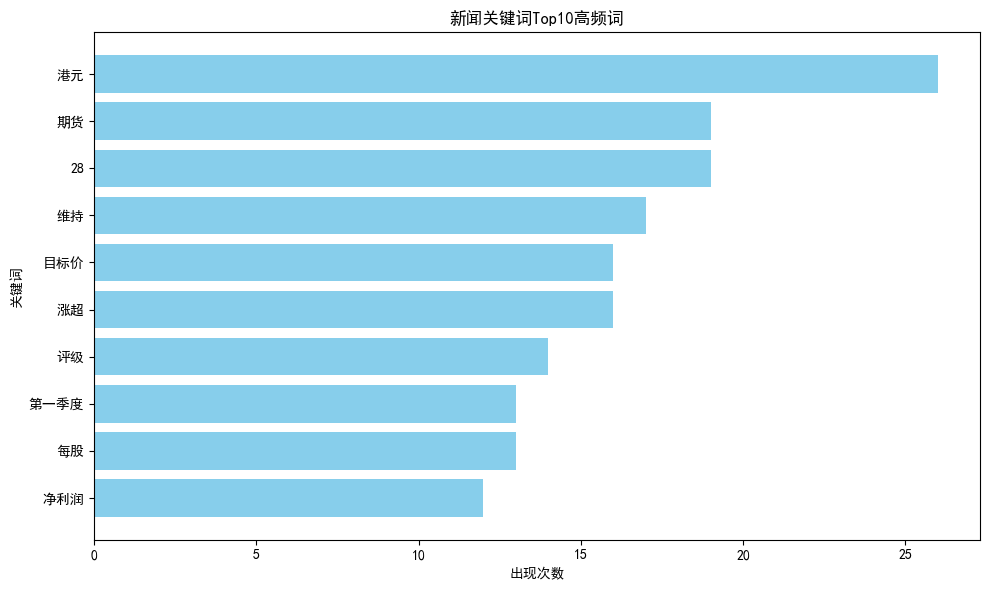

In [70]:
# 七 数据可视化(词频柱状图)

# 1.导入相关库
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文乱码
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

# 2.提取TOP10词和数量
words = [word for word,count in top20_words[:10]] 
counts = [count for word,count in top20_words[:10]]  

# 3.制作图表
plt.figure(figsize=(10,6))
plt.barh(words,counts, color='skyblue')
plt.xlabel('出现次数')
plt.ylabel('关键词')
plt.title('新闻关键词Top10高频词')
plt.gca().invert_yaxis()   # 让高频词显示在顶部
plt.tight_layout()   # 调整子图参数,避免内容被裁剪
plt.savefig('top_words.png',dpi = 300)  
plt.show()

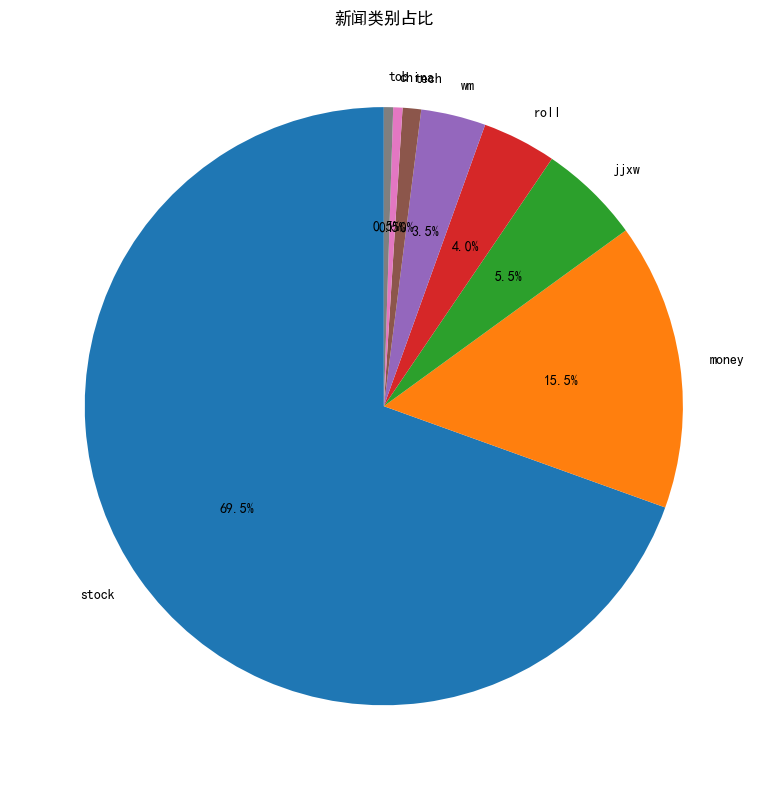

In [77]:
# 八 数据可视化(新闻分类占比拼图)

plt.figure(figsize=(8,8))
plt.pie(category_counts.values,labels = category_counts.index,autopct = '%1.1f%%',startangle=90)
plt.title('新闻类别占比')
plt.tight_layout() 
plt.savefig('category_pie.png',dpi = 300)
plt.show()

In [ ]:
# 九 数据分析(时间趋势折线图)

# 所爬取数据集只有200条,发布时间均为4.27/4.28,无法进行时间趋势分析,直接跳过